<a href="https://colab.research.google.com/github/manuellazarte/Procesamiento-del-Lenguaje-Natural/blob/main/src/TP2_Lazarte_Mendoza_Toledo_Romano_Troanes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP2 — Representación vectorial de texto: embeddings y búsqueda semántica

**Procesamiento del Lenguaje Natural — TUIA, FCEIA-UNR, 2026**

Integrantes: Manuel Lazarte, Emmanuel Mendoza, Álvaro Toledo, Maximiliano Romano, Federico Nahuel Troanes.

Corpus: 150 libros de la categoría **Bélico** de Lectulandia, scrapeados en el TP1 (`data/libros.csv`).

**Antes de correr:** cargar en los *Secrets* de Colab la cadena de conexión de Supabase con el nombre `SUPABASE_DB_URL`. El notebook nunca la escribe ni la imprime.

In [1]:
!pip install -q "gensim>=4.3.3" sentence-transformers "psycopg[binary]" pgvector


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


## A. Recuperar y preparar el corpus

In [2]:
import os
import re
import ast
import json
import numpy as np
import pandas as pd

URL_REPO = "https://raw.githubusercontent.com/manuellazarte/Procesamiento-del-Lenguaje-Natural/main"

def ruta_archivo(nombre):
    # Busca el archivo en el repo clonado o subido a Colab; si no está, usa la URL raw de GitHub
    for ruta in [f"../{nombre}", nombre, f"/content/{os.path.basename(nombre)}"]:
        if os.path.exists(ruta):
            return ruta
    return f"{URL_REPO}/{nombre}"

df = pd.read_csv(ruta_archivo("data/libros.csv"))

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   book_id           150 non-null    int64
 1   titulo            150 non-null    str  
 2   autores           150 non-null    str  
 3   generos           150 non-null    str  
 4   serie             48 non-null     str  
 5   sinopsis          150 non-null    str  
 6   url_libro         150 non-null    str  
 7   categoria_origen  150 non-null    str  
 8   fecha_extraccion  150 non-null    str  
 9   url_portada       150 non-null    str  
dtypes: int64(1), str(9)
memory usage: 11.8 KB


In [4]:
df.head()

,book_id,titulo,autores,generos,serie,sinopsis,url_libro,categoria_origen,fecha_extraccion,url_portada
0,125386,Batallón disciplinario,['Karl von Vereiter'],"['Aventuras', 'Bélico', 'Novela']",NaN,De todas las unidades especiales que la Wehrma...,/book/batallon-disciplinario/,belico,2026-09-07,https://assets.lectulandia.com/b/ab/Karl%20von...
1,125355,Bombardero,['Len Deighton'],"['Bélico', 'Intriga', 'Novela']",NaN,"En una calurosa noche de junio de 1943, una fu...",/book/bombardero/,belico,2026-09-07,https://assets.lectulandia.com/b/ab/Len%20Deig...
2,125294,Las quimeras negras,['Jean Lartéguy'],"['Bélico', 'Novela']",NaN,En medio de un África presa de todos los delir...,/book/las-quimeras-negras/,belico,2026-09-07,https://assets.lectulandia.com/b/ab/Jean%20Lar...
3,125082,Tierra de asilo,['Jean Lartéguy'],"['Bélico', 'Novela']",NaN,Sauveterre es un rincón de la Francia olvidada...,/book/tierra-de-asilo/,belico,2026-09-07,https://assets.lectulandia.com/b/ab/Jean%20Lar...
4,124552,Colina 112,['Adrian Goldsworthy'],"['Bélico', 'Histórico', 'Novela']",NaN,"Se avecina el día D. Sin embargo, para tres jó...",/book/colina-112/,belico,2026-09-07,https://assets.lectulandia.com/b/ab/Adrian%20G...


`autores` y `generos` están guardados como texto con forma de lista de Python (`"['Aventuras', 'Bélico']"`), así que los convertimos a listas.

Todos los libros tienen el género "Bélico", porque el corpus es esa categoría. Para colorear y filtrar usamos un **género secundario**: el primero que no sea "Bélico" ni un formato (Novela, Relato, Poesía, etc.). Si no hay ninguno, el libro queda como "Solo bélico".

In [5]:
df['generos'] = df['generos'].apply(ast.literal_eval)
df['autores'] = df['autores'].apply(ast.literal_eval)

FORMATOS = {'Bélico', 'Novela', 'Relato', 'Poesía', 'Teatro', 'Ensayo', 'Otros'}

def genero_secundario(generos):
    resto = [g for g in generos if g not in FORMATOS]
    return resto[0] if resto else 'Solo bélico'

df['genero_secundario'] = df['generos'].apply(genero_secundario)
df['genero_secundario'].value_counts()

genero_secundario
Solo bélico        34
Aventuras          32
Histórico          28
Drama              27
Intriga            17
Realista            4
Crónica             3
Ciencia ficción     2
Policíaco           1
Distopía            1
Historia            1
Name: count, dtype: int64

### Primer análisis del corpus

**Decisiones de preprocesamiento.** Cada una es una pérdida de información deliberada:

| Decisión | Qué perdemos | ¿La aplicamos? |
|---|---|---|
| Minúsculas | Entidades nombradas (`Malvinas`, `Sharpe`, `Normandía`) dejan de distinguirse de palabras comunes | Sí, para TF-IDF y Word2Vec |
| Sacar acentos | `si`/`sí`, `el`/`él`, `ejército` → `ejercito` | Solo para TF-IDF y el W2V propio. **No** para SBW, porque su vocabulario tiene tildes |
| Sacar puntuación | Límites de oración, comillas que marcan títulos o apodos («el Viejo») | Sí, para TF-IDF y Word2Vec |
| Sacar stopwords | Negaciones (`no`, `sin`, `ni`) y relaciones sintácticas | Sí, para TF-IDF y Word2Vec |

**El preprocesamiento pertenece al modelo, no al corpus.** Por eso armamos **dos versiones** del texto:
- una **limpia y tokenizada** (`sinopsis_limpia`), para los modelos de bolsa de palabras (TF-IDF) y para Word2Vec, que trabajan palabra por palabra;
- la **cruda** (`sinopsis`), para SBERT. Fue entrenado sobre texto natural y usa el orden, la puntuación y las palabras funcionales. Sacarle "no", "sin" o las mayúsculas sería destructivo.

Para SBW agregamos una tercera variante limpia que **conserva los acentos** (`sinopsis_sbw`), porque si no, `ejército` se busca como `ejercito` y queda fuera de vocabulario o cae en una palabra mal escrita.

**Preguntas del primer análisis**

1. *¿Cuántas sinopsis harían falta para que los términos característicos de TF-IDF sean estables? ¿Cómo lo medirían?* No hay un número universal. El IDF de un término depende de en cuántos documentos aparece, y con pocos documentos un término que aparece "por casualidad" en uno solo recibe el IDF máximo. Para medirlo haríamos un submuestreo: tomar subconjuntos de N sinopsis varias veces, calcular el top-10 de términos de cada documento y medir cuánto coinciden esos tops entre submuestras (por ejemplo, con Jaccard). El N a partir del cual la coincidencia deja de subir es el tamaño mínimo razonable. Con 12 documentos es casi ruido. Con nuestras 150 está mejor, pero sigue siendo un corpus chico.
2. *Las sinopsis son texto promocional. ¿Qué sesgo introduce eso en un clasificador de género?* Las sinopsis están escritas para vender: "apasionante", "best-seller", "superventas", "premio Nobel", "obra maestra". Un clasificador aprendería ese vocabulario de marketing, que depende de la editorial y de la época de la edición más que del contenido. Además, los géneros "de moda" tienen sinopsis más infladas. El modelo aprende cómo se vende un libro, no de qué trata.
3. *Un libro tiene varios géneros. ¿Cómo cambia la evaluación respecto de multi-clase?* En multi-clase, cada libro tiene una sola etiqueta correcta y alcanza con el accuracy. En multi-etiqueta hay que evaluar un conjunto de etiquetas por libro: precision/recall/F1 por etiqueta (promediados micro o macro), Hamming loss o *subset accuracy* (acertar el conjunto exacto, que es muy exigente). En nuestro corpus, además, "Bélico" está en el 100 % de los libros: es una etiqueta que no aporta información y que inflaría cualquier métrica.
4. *¿Qué pasa con los libros en gallego o catalán?* La lista de stopwords y el vocabulario de SBW son del español, así que un texto en catalán quedaría casi todo fuera de vocabulario y su vector promedio saldría de muy pocas palabras (o nulo). Lo correcto es detectar el idioma antes de tokenizar (por ejemplo con `langdetect` o el identificador de idioma de fastText) y filtrar esos libros o tratarlos aparte. En nuestro corpus de 150 libros leímos las sinopsis y todas están en español, así que no hizo falta, pero un scraping más grande sí lo necesitaría. El modelo multilingüe de SBERT es el único de los tres que tolera bien otro idioma.

### Preprocesamiento

In [6]:
import unicodedata

# Definimos funcion para remover acentos
def remove_accents(input_str):
    nfkd_form = unicodedata.normalize('NFKD', input_str)
    return ''.join([c for c in nfkd_form if not unicodedata.combining(c)])

In [7]:
# Definimos la lista de stopwords en español
stopwords_es = [
    'de', 'la', 'que', 'el', 'en', 'y', 'a', 'los', 'del', 'se', 'las', 'por', 'un',
    'para', 'con', 'no', 'una', 'su', 'al', 'lo', 'como', 'más', 'pero', 'sus', 'le',
    'ya', 'o', 'este', 'sí', 'porque', 'esta', 'entre', 'cuando', 'muy', 'sin',
    'sobre', 'también', 'me', 'hasta', 'hay', 'donde', 'quien', 'desde', 'todo',
    'nos', 'durante', 'todos', 'uno', 'les', 'ni', 'contra', 'otros', 'ese', 'eso',
    'ante', 'ellos', 'e', 'esto', 'mí', 'antes', 'algunos', 'qué', 'unos', 'yo',
    'otro', 'otras', 'otra', 'él', 'tanto', 'esa', 'estos', 'mucho', 'quienes',
    'nada', 'muchos', 'cual', 'poco', 'ella', 'estar', 'estas', 'algunas', 'algo',
    'nosotros', 'mi', 'mis', 'tú', 'te', 'ti', 'tu', 'tus', 'ellas', 'nosotras',
    'vosotros', 'vosotras', 'os', 'mío', 'mía', 'míos', 'mías', 'tuyo', 'tuya',
    'tuyos', 'tuyas', 'suyo', 'suya', 'suyos', 'suyas', 'nuestro', 'nuestra',
    'nuestros', 'nuestras', 'vuestro', 'vuestra', 'vuestros', 'vuestras', 'es'
]

In [8]:
# Preprocesador para TF-IDF y el W2V propio
def preprocesar_lexico(texto):
    texto = texto.lower() # minusculas
    texto = re.sub(r'[^\w\s]', '', texto) # puntuacion
    palabras = [w for w in texto.split() if w not in stopwords_es] # sacar stopwords
    return remove_accents(" ".join(palabras)) # quitar acentos

# Preprocesador para SBW: igual pero conserva los acentos,
# porque el vocabulario de SBW tiene tildes ('ejército' != 'ejercito')
def preprocesar_sbw(texto):
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto)
    return " ".join(w for w in texto.split() if w not in stopwords_es)

Aplicamos la limpieza en columnas nuevas. La sinopsis cruda (`sinopsis`) queda intacta para SBERT.

In [9]:
df['sinopsis_limpia'] = df['sinopsis'].apply(preprocesar_lexico)
df['sinopsis_sbw'] = df['sinopsis'].apply(preprocesar_sbw)

print("Cruda: ", df['sinopsis'].iloc[0][:200])
print("Limpia:", df['sinopsis_limpia'].iloc[0][:200])
print("SBW:   ", df['sinopsis_sbw'].iloc[0][:200])

Cruda:  De todas las unidades especiales que la Wehrmacht poseyó en el transcurso de la Segunda Guerra Mundial, ninguna fue tan tremendamente inhumana como los llamados batallones disciplinarios. Si pensamos 
Limpia: todas unidades especiales wehrmacht poseyo transcurso segunda guerra mundial ninguna fue tan tremendamente inhumana llamados batallones disciplinarios si pensamos ejercito aleman era duda fuerza rigid
SBW:    todas unidades especiales wehrmacht poseyó transcurso segunda guerra mundial ninguna fue tan tremendamente inhumana llamados batallones disciplinarios si pensamos ejército alemán era duda fuerza rígid


Tokenización

In [10]:
# Creamos las listas de oraciones tokenizadas
corpus_tokens = [texto.split() for texto in df['sinopsis_limpia']]
corpus_tokens_sbw = [texto.split() for texto in df['sinopsis_sbw']]

## B. Word2Vec / FastText: propio contra pre-entrenado

In [11]:
from gensim.models import Word2Vec

modelo_propio = Word2Vec(
    sentences=corpus_tokens,
    vector_size=300, # igual que SBW, para comparar en la misma dimension
    window=5, # en las sinopsis las palabras relacionadas no siempre estan pegadas
    min_count=3, # con 1 aprende vectores de palabras vistas una sola vez (ruido); con 5 pierde mucho vocabulario
    sg=1, # skip-gram: funciona mejor que CBOW con palabras poco frecuentes y corpus chicos
    negative=5, # negative sampling (5 palabras negativas por ejemplo)
    epochs=30, # como es un corpus chico necesita muchas pasadas para converger
    seed=42, # inicializacion
    workers=1 # un solo hilo para que la seed sea reproducible
)

print(f"Palabras en el vocabulario propio: {len(modelo_propio.wv)}")

Palabras en el vocabulario propio: 1206


**Justificación de los parámetros**

- `vector_size=300`: es la dimensión de SBW, así los dos modelos se comparan en el mismo espacio de dimensión. Con 150 documentos, 300 dimensiones son muchas para lo que hay para aprender, y es una de las razones por las que el modelo propio queda subentrenado (ver vecinos).
- `window=5`: una sinopsis es prosa y las palabras relacionadas (`submarino` ... `hundido`) suelen estar a varias posiciones de distancia. Una ventana de 2 vería solo la sintaxis local.
- `min_count=3`: con `min_count=1`, el modelo aprende vectores para palabras vistas una sola vez, que salen prácticamente al azar. Con 5, el vocabulario de un corpus tan chico se reduce demasiado. 3 es un punto intermedio.
- `sg=1` (skip-gram): predice el contexto a partir de la palabra central, así que cada aparición de una palabra rara genera varios ejemplos de entrenamiento. CBOW promedia el contexto y favorece a las palabras frecuentes.
- `epochs=30`: el default (5) no alcanza para converger con tan pocos datos.

**Negative sampling: qué optimiza el modelo.** Skip-gram quiere maximizar la probabilidad de las palabras del contexto dada la palabra central. Hacerlo con un softmax exige normalizar sobre **todo el vocabulario** en cada paso: con SBW, casi un millón de productos escalares por ejemplo. Es inviable. Negative sampling reemplaza ese softmax por un problema binario: distinguir el par real (palabra, contexto) de `negative=5` pares falsos, cuyas palabras se sortean según su frecuencia. Cada paso actualiza 6 vectores en lugar del vocabulario entero.

In [12]:
from gensim.models import KeyedVectors

sbw_file = "SBW-vectors-300-min5.bin.gz"

# Descargamos el modelo pre-entrenado si no existe en Colab
if not os.path.exists(sbw_file):
    print("Descargando modelo SBW-vectors-300-min5 (aprox. 1 GB)...")
    !wget -q https://cs.famaf.unc.edu.ar/~ccardellino/SBWCE/SBW-vectors-300-min5.bin.gz

# Carga con Gensim KeyedVectors
modelo_sbw = KeyedVectors.load_word2vec_format(sbw_file, binary=True)
print(f"Modelo SBW cargado. Vocabulario: {len(modelo_sbw.key_to_index)} palabras.")

Modelo SBW cargado. Vocabulario: 1000653 palabras.


Vecinos más cercanos de palabras del dominio, en los dos modelos. Para SBW se busca la forma **con acento** (`ejército`), porque así está en su vocabulario.

In [13]:
# (palabra en el modelo propio, palabra en SBW)
palabras_dominio = [('guerra', 'guerra'), ('soldado', 'soldado'), ('ejercito', 'ejército'),
                    ('batalla', 'batalla'), ('submarino', 'submarino')]

comparacion = []

for palabra_propio, palabra_sbw in palabras_dominio:
    # Vecinos en el modelo propio
    if palabra_propio in modelo_propio.wv:
        vecinos_propio = [f"{w} ({sim:.2f})" for w, sim in modelo_propio.wv.most_similar(palabra_propio, topn=5)]
    else:
        vecinos_propio = ["OOV (fuera de vocabulario)"]

    # Vecinos en el modelo pre-entrenado (SBW)
    if palabra_sbw in modelo_sbw:
        vecinos_sbw = [f"{w} ({sim:.2f})" for w, sim in modelo_sbw.most_similar(palabra_sbw, topn=5)]
    else:
        vecinos_sbw = ["OOV"]

    comparacion.append({
        "Palabra": palabra_sbw,
        "Vecinos Modelo Propio": ", ".join(vecinos_propio),
        "Vecinos Modelo SBW (Pre-entrenado)": ", ".join(vecinos_sbw)
    })

df_vecinos = pd.DataFrame(comparacion)
pd.set_option('display.max_colwidth', None)
df_vecinos

,Palabra,Vecinos Modelo Propio,Vecinos Modelo SBW (Pre-entrenado)
0,guerra,"bolchevique (0.96), pacifico (0.96), segunda (0.96), batallas (0.95), rusa (0.95)","Guerra (0.74), guerras (0.69), francoprusiana (0.64), bélica (0.64), batalla (0.64)"
1,soldado,"raso (0.93), regimiento (0.90), castigo (0.89), aleman (0.89), infanteria (0.88)","combatiente (0.72), suboficial (0.68), sargento (0.67), soldados (0.66), miliciano (0.65)"
2,ejército,"unirse (0.90), italiano (0.90), regimiento (0.90), frances (0.90), raso (0.89)","ejercito (0.81), tropas (0.79), ejércitos (0.79), infantería (0.74), soldados (0.74)"
3,batalla,"muhlberg (0.92), linea (0.92), grossman (0.91), centra (0.91), 1937 (0.91)","Batalla (0.83), batallas (0.77), escaramuza (0.73), librada (0.68), Fehrbellin (0.67)"
4,submarino,"ingles (0.94), traves (0.94), pudo (0.94), base (0.94), regresa (0.93)","sumergible (0.80), submarinos (0.77), buque (0.71), minisubmarino (0.70), torpedo (0.69)"


**Lectura de los vecinos.** El W2V propio devuelve similitudes de 0.89 a 0.96 con palabras que no son sinónimos ni del mismo campo: los vecinos de *submarino* son *ingles, traves, pudo, base, regresa*, y los de *batalla* son *muhlberg, linea, grossman, centra, 1937*. El modelo no aprendió semántica, aprendió **coocurrencia dentro de unas pocas sinopsis**. "Submarino" aparece en un puñado de libros, y sus "vecinos" son las palabras que lo acompañan justo en esos libros. Con 150 documentos y unas 1200 palabras en el vocabulario, cada palabra tiene muy pocos contextos, y todos los vectores terminan apuntando a direcciones parecidas (lo confirma la distribución de pares aleatorios de la parte D).

SBW, en cambio, devuelve vecinos con sentido:
- sinónimos (*sumergible*, *combatiente*, *escaramuza*);
- flexiones (*soldados*, *ejércitos*, *batallas*);
- palabras del mismo campo (*torpedo*, *sargento*, *infantería*).

Sus similitudes son más bajas (0.64 a 0.83), pero mucho más informativas. Dos detalles más: SBW distingue mayúsculas (*Guerra* y *Batalla* aparecen como vecinos de sí mismas), y el vecino más cercano de *ejército* es *ejercito* sin tilde. La forma sin tilde existe en SBW como variante mal escrita, con su propio vector: por eso conviene conservar los acentos al buscar en SBW.

### Vector de documento: promedio de vectores de palabra

El vector de cada documento es el **promedio** de los vectores de sus palabras que están en el vocabulario del modelo. Las palabras fuera de vocabulario se descartan. Si un documento no tiene **ninguna** palabra conocida, la función devuelve `None` en lugar de un vector de ceros: así el nulo queda explícito y no se cuela como un vector "válido" que después, al normalizar, se convierte en `NaN`.

In [14]:
def vectorizar_documento_promedio(tokens, modelo):
    """Promedio de los vectores de las palabras del documento que estan en el vocabulario."""
    # si pasamos modelo_propio accedemos a .wv, si es KeyedVectors (SBW) directamente al objeto
    wv = modelo.wv if hasattr(modelo, 'wv') else modelo

    vectores_palabras = [wv[w] for w in tokens if w in wv]

    if len(vectores_palabras) == 0:
        return None  # ninguna palabra conocida: nulo explicito

    return np.mean(vectores_palabras, axis=0)

def cobertura(corpus, modelo):
    # % de tokens del corpus que el modelo encuentra en su vocabulario
    wv = modelo.wv if hasattr(modelo, 'wv') else modelo
    total = sum(len(tokens) for tokens in corpus)
    encontrados = sum(1 for tokens in corpus for w in tokens if w in wv)
    return encontrados / total

df['vector_w2v_propio'] = [vectorizar_documento_promedio(t, modelo_propio) for t in corpus_tokens]
df['vector_w2v_sbw'] = [vectorizar_documento_promedio(t, modelo_sbw) for t in corpus_tokens_sbw]

pd.DataFrame([
    {"Modelo": "W2V propio", "Cobertura de tokens": cobertura(corpus_tokens, modelo_propio),
     "Docs con vector nulo": df['vector_w2v_propio'].isna().sum()},
    {"Modelo": "SBW sin acentos (preproc. léxico)", "Cobertura de tokens": cobertura(corpus_tokens, modelo_sbw),
     "Docs con vector nulo": sum(vectorizar_documento_promedio(t, modelo_sbw) is None for t in corpus_tokens)},
    {"Modelo": "SBW con acentos", "Cobertura de tokens": cobertura(corpus_tokens_sbw, modelo_sbw),
     "Docs con vector nulo": df['vector_w2v_sbw'].isna().sum()},
]).round(3)

,Modelo,Cobertura de tokens,Docs con vector nulo
0,W2V propio,0.576,0
1,SBW sin acentos (preproc. léxico),0.934,0
2,SBW con acentos,0.945,0


El W2V propio cubre solo el **57.6 %** de los tokens del corpus, porque `min_count=3` descarta las palabras que aparecen menos de 3 veces, que en un corpus chico son la mayoría. SBW cubre el **93.4 %** con el texto sin acentos y el **94.5 %** conservándolos: un punto más de cobertura solo por no destruir los acentos.

Ningún documento quedó con vector nulo: todas las sinopsis tienen al menos una palabra conocida. Igual dejamos el manejo explícito, porque una **consulta** sí puede quedarse sin vector: le pasa al W2V propio con la consulta q14 (ver la evaluación).

**¿Qué más se pierde al promediar, además del orden?**
- **La negación y la composición.** "sobrevivió a la guerra" y "no sobrevivió a la guerra" quedan casi iguales (y "no" ya se fue con las stopwords).
- **El peso relativo de las palabras.** Todas pesan lo mismo: un "años" o un "historia", que aparecen en todas las sinopsis, cuentan tanto como "submarino" o "Malvinas", que son las que identifican al libro.
- **Dilución en textos largos.** Cuantas más palabras se promedian, más se parece el vector al "centro" del espacio. Las sinopsis largas tienden a parecerse entre sí aunque hablen de cosas distintas.
- **Lo que está fuera de vocabulario.** Nombres propios, palabras raras o mal escritas desaparecen sin aviso. Justamente suelen ser las más informativas.
- **La polisemia.** Cada palabra tiene un solo vector, mezcla de todos sus sentidos ("carga" de caballería y "carga" de un barco).

**¿Por qué lo usamos igual?** Es simple, rápido, no necesita GPU y es fácil de explicar y de reproducir. Además, es la línea de base natural de la familia "word vectors": si un modelo de oración no le gana a un promedio, algo anda mal.

**Elección para persistir:** guardamos en la base el promedio con **SBW** (con acentos). Tiene mucha más cobertura de vocabulario que el propio y sus vectores vienen de miles de millones de palabras, no de 150 sinopsis. El W2V propio se sigue evaluando en Python, como comparación.

## C. Modelo de oración: SBERT

Usamos `distiluse-base-multilingual-cased-v1`, el de la Unidad 2. Recibe la **sinopsis cruda**.

In [15]:
from sentence_transformers import SentenceTransformer

modelo_sbert = SentenceTransformer('distiluse-base-multilingual-cased-v1')

print("Dimensión del embedding:", modelo_sbert.get_sentence_embedding_dimension())
print("Límite de tokens (max_seq_length):", modelo_sbert.max_seq_length)

/usr/local/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dimensión del embedding: 512
Límite de tokens (max_seq_length): 128


/tmp/ipykernel_513/4061914520.py:5: FutureWarning: The `get_sentence_embedding_dimension` method has been renamed to `get_embedding_dimension`.
  print("Dimensión del embedding:", modelo_sbert.get_sentence_embedding_dimension())


El modelo **no avisa** cuando trunca: corta en silencio todo lo que pase de `max_seq_length` tokens. Para saber cuántas sinopsis se truncan, las tokenizamos con el mismo tokenizer del modelo (contando los tokens especiales) y las comparamos contra el límite.

In [16]:
n_tokens = np.array([len(modelo_sbert.tokenizer(t)['input_ids']) for t in df['sinopsis']])
df['n_tokens_sbert'] = n_tokens

limite = modelo_sbert.max_seq_length
truncadas = n_tokens > limite

print(f"Tokens por sinopsis: media {n_tokens.mean():.0f}, mediana {np.median(n_tokens):.0f}, máximo {n_tokens.max()}")
print(f"Sinopsis truncadas (> {limite} tokens): {truncadas.sum()} de {len(df)} ({truncadas.mean():.1%})")
print(f"Tokens descartados en promedio entre las truncadas: {(n_tokens[truncadas] - limite).mean():.0f}")

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (253 > 128). Running this sequence through the model will result in indexing errors


Tokens por sinopsis: media 252, mediana 246, máximo 583
Sinopsis truncadas (> 128 tokens): 141 de 150 (94.0%)
Tokens descartados en promedio entre las truncadas: 134


**El dato importante: 141 de las 150 sinopsis (94 %) superan los 128 tokens del modelo y se truncan.** La sinopsis media tiene 252 tokens, así que el modelo ve, en promedio, la mitad del texto, y en las truncadas se pierden 134 tokens en promedio. Lo que se pierde es el **final**. En una sinopsis promocional eso suele ser el cierre comercial (premios, crítica, "una obra maestra..."), así que a veces el truncado no hace daño. Pero cuando el dato que identifica al libro está al final, SBERT no lo ve.

Además, el tokenizer (WordPiece) parte las palabras raras y los nombres propios en varios sub-tokens (`Chechenia` → `Che ##chen ##ia`), y eso consume el presupuesto de 128 más rápido de lo que sugiere la cantidad de palabras.

In [17]:
emb_sbert = modelo_sbert.encode(df['sinopsis'].tolist(), show_progress_bar=True)
print(emb_sbert.shape)

Batches:   0%|          | 0/5 [00:00<?, ?it/s]

Batches:  20%|██        | 1/5 [00:02<00:08,  2.02s/it]

Batches:  40%|████      | 2/5 [00:03<00:05,  1.92s/it]

Batches:  60%|██████    | 3/5 [00:05<00:03,  1.79s/it]

Batches:  80%|████████  | 4/5 [00:07<00:01,  1.75s/it]

Batches: 100%|██████████| 5/5 [00:08<00:00,  1.51s/it]

Batches: 100%|██████████| 5/5 [00:08<00:00,  1.65s/it]

(150, 512)


### Línea de base léxica: TF-IDF

Es la representación de bolsa de palabras de la Unidad 2. Se construye sobre la `sinopsis_limpia`.

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()
X_tfidf = tfidf.fit_transform(df['sinopsis_limpia'])
print("Matriz TF-IDF:", X_tfidf.shape, f"- {X_tfidf.nnz / np.prod(X_tfidf.shape):.1%} de celdas no nulas")

Matriz TF-IDF: (150, 6137) - 1.4% de celdas no nulas


Armamos las matrices de documentos de cada modelo y las guardamos en disco, así no hay que recalcular nada si se reinicia Colab. Los documentos con vector nulo quedan como una fila de ceros, marcados en una máscara (`con_vector`) para no recuperarlos.

In [19]:
def a_matriz(vectores, dim=300):
    return np.vstack([v if v is not None else np.zeros(dim) for v in vectores])

X_w2v_propio = a_matriz(df['vector_w2v_propio'])
X_w2v_sbw = a_matriz(df['vector_w2v_sbw'])

os.makedirs("embeddings", exist_ok=True)
np.save("embeddings/w2v_propio.npy", X_w2v_propio)
np.save("embeddings/w2v_sbw.npy", X_w2v_sbw)
np.save("embeddings/sbert.npy", emb_sbert)

## D. Comparación y visualización

Para comparar los espacios, cada modelo recibe la consulta con **su propio preprocesamiento**: TF-IDF y el W2V propio, la versión léxica (sin acentos); SBW, la versión con acentos; SBERT, el texto crudo. Mezclarlos sería un error silencioso: la consulta y los documentos quedarían en "idiomas" distintos.

`rankear` resuelve la similitud coseno en Python. Sirve solo para comparar; la búsqueda real en SQL está en la parte F.

**Criterio de "recuperado":**
- En TF-IDF, un documento que no comparte ningún término con la consulta tiene similitud exactamente 0. Si lo dejáramos en el ranking, su posición entre los empates la decidiría el orden del índice, y podría "acertar" por casualidad. Por eso solo cuentan como recuperados los documentos con similitud > 0. Si hay menos de k, los lugares vacíos cuentan como fallos.
- En los embeddings, se excluyen los documentos con vector nulo.

In [20]:
from sklearn.metrics.pairwise import cosine_similarity

def vector_consulta_w2v(consulta, modelo, preprocesar):
    return vectorizar_documento_promedio(preprocesar(consulta).split(), modelo)

MODELOS = {
    'TF-IDF':     {'docs': X_tfidf,      'con_vector': np.ones(len(df), dtype=bool),
                   'embeber': lambda q: tfidf.transform([preprocesar_lexico(q)])},
    'W2V propio': {'docs': X_w2v_propio, 'con_vector': df['vector_w2v_propio'].notna().values,
                   'embeber': lambda q: vector_consulta_w2v(q, modelo_propio, preprocesar_lexico)},
    'W2V SBW':    {'docs': X_w2v_sbw,    'con_vector': df['vector_w2v_sbw'].notna().values,
                   'embeber': lambda q: vector_consulta_w2v(q, modelo_sbw, preprocesar_sbw)},
    'SBERT':      {'docs': emb_sbert,    'con_vector': np.ones(len(df), dtype=bool),
                   'embeber': lambda q: modelo_sbert.encode([q])},
}

def rankear(consulta, nombre, k=10):
    """Devuelve (book_ids, similitudes) de los k documentos mas parecidos a la consulta."""
    m = MODELOS[nombre]
    q = m['embeber'](consulta)
    if q is None:  # la consulta no tiene ninguna palabra en el vocabulario
        return [], np.array([])
    if not hasattr(q, 'nnz'):
        q = np.asarray(q).reshape(1, -1)
    sims = cosine_similarity(q, m['docs']).ravel()

    if nombre == 'TF-IDF':
        candidatos = np.where(sims > 0)[0]  # sin terminos en comun = no recuperado
    else:
        candidatos = np.where(m['con_vector'])[0]
    orden = candidatos[np.argsort(-sims[candidatos], kind='stable')][:k]
    return df['book_id'].values[orden].tolist(), sims[orden]

### Ranking lado a lado

In [21]:
titulo_de = dict(zip(df['book_id'], df['titulo']))

def tabla_lado_a_lado(consulta, k=5):
    columnas = {}
    for nombre in MODELOS:
        ids, sims = rankear(consulta, nombre, k)
        filas = [f"{titulo_de[i][:40]} ({s:.2f})" for i, s in zip(ids, sims)]
        columnas[nombre] = filas + ["—"] * (k - len(filas))
    return pd.DataFrame(columnas, index=range(1, k + 1))

consultas_demo = [
    "una novela sobre soldados que luchan en el desierto",
    "historias de amor en medio de la guerra",
    "batallas navales entre barcos de guerra",
]
for c in consultas_demo:
    print(f"\nConsulta: {c}")
    display(tabla_lado_a_lado(c))


Consulta: una novela sobre soldados que luchan en el desierto


,TF-IDF,W2V propio,W2V SBW,SBERT
1,El baile de los malditos (0.14),Ocho hacia la eternidad (0.99),El baile de los malditos (0.77),Las aventuras de Wesley Jackson (0.45)
2,Los perros de Essex (0.12),Las aventuras de Wesley Jackson (0.98),La guerra de Courtney (0.76),Aunque caminen por el valle de la muerte (0.43)
3,El cuerpo humano (0.08),Cuentos de la Guerra Civil (0.98),Ejecución (0.76),El fuego (0.42)
4,Aunque caminen por el valle de la muerte (0.07),El cuerpo humano (0.98),Muerte al invasor (0.75),Los años de bronce (0.42)
5,Los lobos de invierno (0.07),Tenko (0.98),Los perros de Essex (0.75),Guerra (0.41)



Consulta: historias de amor en medio de la guerra


,TF-IDF,W2V propio,W2V SBW,SBERT
1,Rendidos (0.11),Los años de bronce (0.98),El Don apacible – Vol I [Tr. José Laín E (0.84),El italiano (0.45)
2,El general del ejercito muerto (0.08),El presagio de los buitres (0.98),El Don apacible (Tr. José Laín Entralgo) (0.83),El presagio de los buitres (0.43)
3,La esposa del prisionero (0.08),Matadero cinco (trad. Temprano García) (0.98),Los centuriones (0.82),Guerra (0.42)
4,Puerto secreto (0.08),Cuentos de la Guerra Civil (0.98),Guerra (0.82),Los años de bronce (0.40)
5,Homero y su Ilíada (0.08),Guerra (0.97),La guerra de Courtney (0.82),Pretoriano (0.37)



Consulta: batallas navales entre barcos de guerra


,TF-IDF,W2V propio,W2V SBW,SBERT
1,60 minutos en el infierno (0.17),Guerra (0.94),Muerte al invasor (0.76),Exocet (0.44)
2,El vuelo del Intruder (0.08),El baile de los malditos (0.93),Bautismo de fuego (0.73),Misión en el Cuerno de Oro (0.43)
3,Exocet (0.08),El Don apacible (Tr. José Laín Entralgo) (0.92),60 minutos en el infierno (0.72),El corsario del oro negro (0.40)
4,La presa de Sharpe (0.07),El Don apacible – Vol I [Tr. José Laín E (0.92),El relojero de la guerra (0.69),Bautismo de fuego (0.40)
5,El comisario (0.07),Matadero cinco (trad. Temprano García) (0.92),Ángeles de acero (0.68),La noche del zorro (0.39)


**Qué se ve en las tres consultas**
- **W2V propio**: similitudes de 0.92 a 0.99 para todo, y los mismos libros se repiten de una consulta a otra ("Guerra", "Matadero cinco", "Cuentos de la Guerra Civil"). Son sinopsis largas y genéricas, cuyo promedio cae cerca del "centro" del espacio. No discrimina.
- **W2V SBW**: mejor en "batallas navales" (*Bautismo de fuego*, *60 minutos en el infierno*, *El relojero de la guerra*, todas de guerra naval). En "historias de amor" ocupa dos de los cinco puestos con el mismo libro (las dos ediciones de *El Don apacible*), y las similitudes están todas entre 0.68 y 0.84: poca separación entre el primero y el quinto.
- **TF-IDF**: similitudes bajas (0.07 a 0.19), que dependen de que aparezca la palabra exacta. *60 minutos en el infierno* gana "batallas navales" porque es la que más términos comparte con la consulta. *Rendidos* gana "historias de amor" porque contiene "amor".
- **SBERT**: los resultados más coherentes con el tema. "Batallas navales" devuelve *Exocet*, *Misión en el Cuerno de Oro* y *Bautismo de fuego*. "Desierto" pone segunda a *Aunque caminen por el valle de la muerte* (Irak). "Historias de amor" pone primero a *El italiano*, cuya sinopsis dice "una historia de amor, mar y guerra".

Esto es solo una impresión cualitativa sobre 3 consultas. La medición está en la sección de evaluación.

### Distribución de similitudes entre pares aleatorios

Que el ranking devuelva resultados no dice nada si en el espacio **todo se parece a todo**. Tomamos 2000 pares de documentos al azar (distintos entre sí y con vector) y miramos cómo se distribuye el coseno en cada modelo.

,media,desvío,mínimo,máximo
TF-IDF,0.021,0.017,0.000,0.234
W2V propio,0.966,0.027,0.782,0.995
W2V SBW,0.904,0.033,0.747,0.965
SBERT,0.283,0.090,0.037,0.631


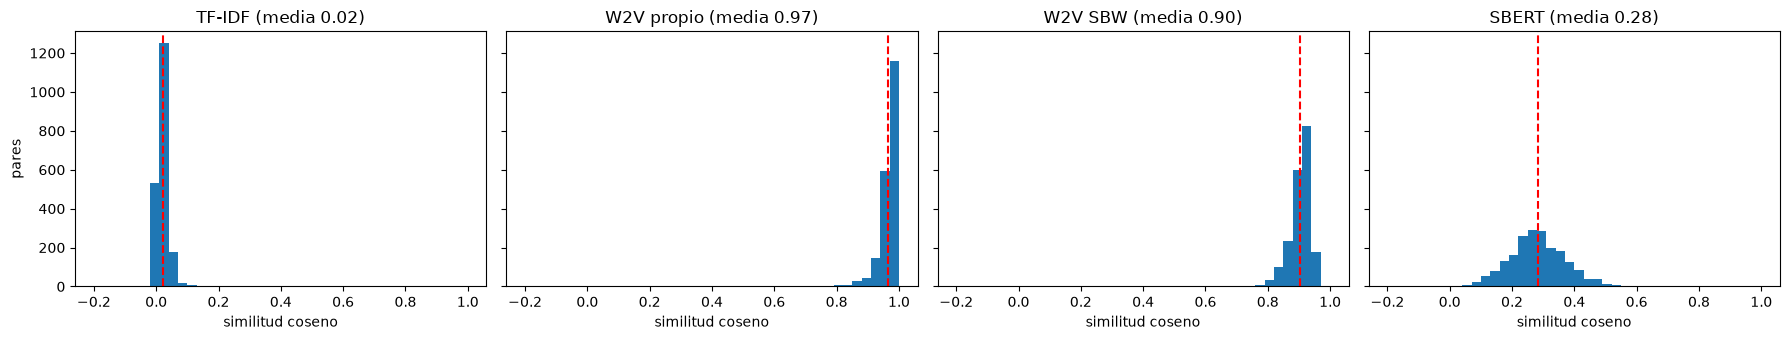

In [22]:
import matplotlib.pyplot as plt

rng = np.random.default_rng(42)
N_PARES = 2000

def similitudes_pares_aleatorios(nombre):
    m = MODELOS[nombre]
    idx = np.where(m['con_vector'])[0]
    i = rng.choice(idx, N_PARES)
    j = rng.choice(idx, N_PARES)
    distintos = i != j
    i, j = i[distintos], j[distintos]
    X = m['docs']
    sims = [cosine_similarity(X[a:a+1] if hasattr(X, 'nnz') else X[a].reshape(1, -1),
                              X[b:b+1] if hasattr(X, 'nnz') else X[b].reshape(1, -1))[0, 0]
            for a, b in zip(i, j)]
    return np.array(sims)

pares = {nombre: similitudes_pares_aleatorios(nombre) for nombre in MODELOS}

display(pd.DataFrame({nombre: {"media": s.mean(), "desvío": s.std(), "mínimo": s.min(), "máximo": s.max()}
                      for nombre, s in pares.items()}).T.round(3))

fig, axes = plt.subplots(1, 4, figsize=(18, 3.5), sharey=True)
for ax, (nombre, s) in zip(axes, pares.items()):
    ax.hist(s, bins=40, range=(-0.2, 1))
    ax.axvline(s.mean(), color='red', linestyle='--')
    ax.set_title(f"{nombre} (media {s.mean():.2f})")
    ax.set_xlabel("similitud coseno")
axes[0].set_ylabel("pares")
plt.tight_layout()
plt.show()

**Interpretación**
- **TF-IDF** (media 0.02): casi todos los pares son ortogonales porque comparten muy pocas palabras. Discrimina, pero solo por coincidencia léxica.
- **W2V propio** (media 0.97, desvío 0.03, mínimo 0.78): **todo se parece a todo**. Todos los vectores de documento caen en un cono angosto, y entre el primer y el quincuagésimo resultado de un ranking hay centésimas de diferencia. Es la combinación de corpus chico y promedio.
- **W2V SBW** (media 0.90): el mismo problema, algo menos marcado. Promediar unas 100 palabras lleva a todos los documentos hacia el "vector medio" del español, dominado por las palabras frecuentes. El ranking igual puede funcionar, porque importa el orden y no el valor, pero el margen es mínimo y un poco de ruido lo da vuelta. Una mejora conocida es restar la media del corpus antes de comparar (centrar los vectores).
- **SBERT** (media 0.28, desvío 0.09, rango 0.04 a 0.63): es el único espacio con dispersión real. Dos sinopsis al azar se parecen poco, y las que se parecen de verdad se destacan.

**Consecuencia práctica:** un umbral fijo de similitud ("mostrar si > 0.5") no significa lo mismo en cada modelo. En los dos W2V devolvería el corpus entero.

### Proyección 2D coloreada por género

Proyectamos los documentos con **PCA** sobre las dos primeras componentes y los coloreamos por el género secundario, una etiqueta que ningún modelo vio al entrenarse.

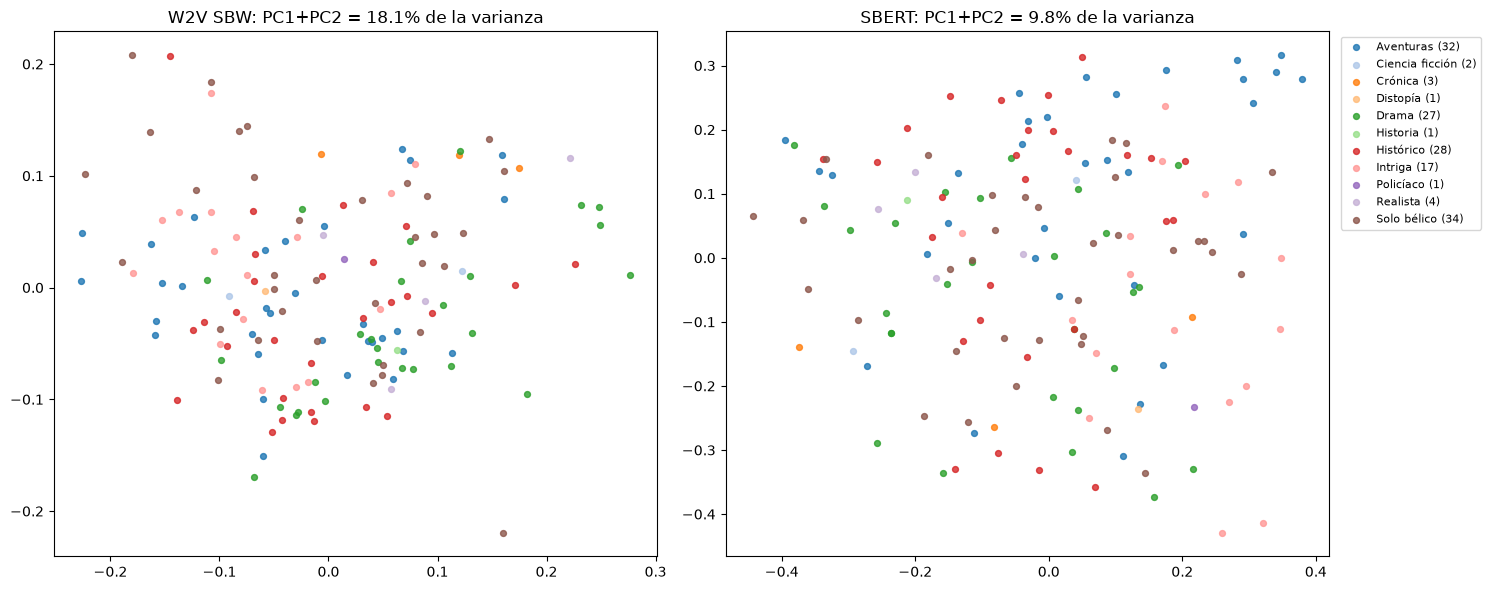

Varianza explicada W2V SBW: [0.116 0.066] | SBERT: [0.052 0.046]


In [23]:
from sklearn.decomposition import PCA

def proyectar(ax, nombre):
    m = MODELOS[nombre]
    idx = np.where(m['con_vector'])[0]
    X = m['docs'][idx]
    X = X / np.linalg.norm(X, axis=1, keepdims=True)  # misma escala que el coseno
    pca = PCA(n_components=2, random_state=42)
    P = pca.fit_transform(X)
    generos = df['genero_secundario'].values[idx]
    for n, g in enumerate(sorted(set(generos))):
        sel = generos == g
        ax.scatter(P[sel, 0], P[sel, 1], s=18, label=f"{g} ({sel.sum()})", alpha=0.8,
                   color=plt.cm.tab20(n))  # tab20: hay mas de 10 generos
    var = pca.explained_variance_ratio_
    ax.set_title(f"{nombre}: PC1+PC2 = {var.sum():.1%} de la varianza")
    return var

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
var_w2v = proyectar(axes[0], 'W2V SBW')
var_sbert = proyectar(axes[1], 'SBERT')
axes[1].legend(bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()
print(f"Varianza explicada W2V SBW: {var_w2v.round(3)} | SBERT: {var_sbert.round(3)}")

Las dos primeras componentes explican solo el **18.1 %** de la varianza en W2V SBW y el **9.8 %** en SBERT. En ninguno de los dos se ven grupos por género: los colores aparecen mezclados.

Con más del 80 % de la varianza fuera del gráfico, eso **no** alcanza para concluir que el espacio no separa géneros. Además, el género secundario es una etiqueta ruidosa: "Solo bélico", "Drama" o "Aventuras" no describen lo que más distingue a estas sinopsis entre sí, que es la época y el frente (napoleónicas, Primera Guerra, Vietnam...).

**Advertencia metodológica.** PCA es una proyección lineal: muestra la "sombra" de los puntos sobre el plano de mayor varianza. Todo lo que no entra en esas dos componentes, que es la mayor parte de la varianza, se descarta. Una nube que en 2D parece mezclada puede estar bien separada en las 300 o 512 dimensiones originales. Al revés, dos puntos que se ven cerca pueden estar lejos. La figura sirve para explorar, no para concluir que el espacio "no separa los géneros".

## E. Persistencia e indexado en Postgres (Supabase + pgvector)

La cadena de conexión se lee de los **Secrets de Colab** (`SUPABASE_DB_URL`) o de una variable de entorno. Nunca se escribe en el notebook ni se imprime.

`prepare_threshold=None` desactiva los *prepared statements* de psycopg, que no funcionan a través del pooler de Supabase (puerto 6543).

In [24]:
import psycopg
from pgvector.psycopg import register_vector

try:
    from google.colab import userdata
    DB_URL = userdata.get('SUPABASE_DB_URL')
except ImportError:
    DB_URL = os.environ.get('SUPABASE_DB_URL')

assert DB_URL, "Falta SUPABASE_DB_URL en los Secrets de Colab o en las variables de entorno"

conn = psycopg.connect(DB_URL, autocommit=True, prepare_threshold=None)
conn.execute("CREATE EXTENSION IF NOT EXISTS vector")
register_vector(conn)

version_pgvector = conn.execute("SELECT extversion FROM pg_extension WHERE extname = 'vector'").fetchone()[0]
print("pgvector habilitado, versión", version_pgvector)

pgvector habilitado, versión 0.8.7


### Tabla `books`

Los géneros y los autores se guardan como `text[]`, así se pueden filtrar con `= ANY(generos)`.

In [25]:
conn.execute("DROP TABLE IF EXISTS emb_w2v, emb_sbert, books")
conn.execute("""
    CREATE TABLE books (
        book_id   bigint PRIMARY KEY,
        titulo    text NOT NULL,
        autores   text[],
        generos   text[],
        serie     text,
        sinopsis  text NOT NULL,
        url_libro text
    )
""")

filas_books = [
    (int(r.book_id), r.titulo, r.autores, r.generos,
     None if pd.isna(r.serie) else r.serie, r.sinopsis, r.url_libro)
    for r in df.itertuples()
]
with conn.cursor() as cur:
    cur.executemany("INSERT INTO books VALUES (%s, %s, %s, %s, %s, %s, %s)", filas_books)

print("Libros en la base:", conn.execute("SELECT count(*) FROM books").fetchone()[0])

Libros en la base: 150


### Una tabla por modelo

- `emb_w2v`: promedio de vectores de SBW, `vector(300)`.
- `emb_sbert`: `distiluse-base-multilingual-cased-v1`, `vector(512)`.

Son de **familias distintas**: un promedio de word vectors y un modelo de oración.

**¿Por qué no pueden convivir dos dimensiones en la misma columna indexada?** El tipo `vector(n)` fija la dimensión: Postgres rechaza insertar un vector de 300 en una columna `vector(512)`. Se podría usar `vector` sin dimensión, pero el índice HNSW **necesita una dimensión fija** para construirse: no se puede indexar una columna con dimensiones mixtas. Y aunque se pudiera, comparar un vector de W2V con uno de SBERT no tiene sentido: son espacios distintos, entrenados con objetivos distintos, y sus coordenadas no se corresponden.

**Manejo explícito de nulos y no finitos antes de insertar.** Cada vector pasa por un filtro:
- `None` (documento sin ninguna palabra en el vocabulario) → se descarta;
- vector con `NaN`/`inf` o con norma 0 → se descarta, porque normalizarlo daría `NaN`.

Los que pasan se **normalizan a norma 1 (L2)**. Se informa cuántos se descartan y por qué.

In [26]:
def preparar_para_insertar(ids, vectores):
    filas, descartados = [], []
    for book_id, v in zip(ids, vectores):
        if v is None:
            descartados.append((book_id, 'vector nulo'))
            continue
        v = np.asarray(v, dtype=np.float32)
        norma = np.linalg.norm(v)
        if not np.all(np.isfinite(v)) or not np.isfinite(norma) or norma == 0:
            descartados.append((book_id, 'no finito o norma 0'))
            continue
        filas.append((int(book_id), v / norma))
    return filas, descartados

filas_w2v, desc_w2v = preparar_para_insertar(df['book_id'], df['vector_w2v_sbw'])
filas_sbert, desc_sbert = preparar_para_insertar(df['book_id'], list(emb_sbert))

print(f"W2V SBW: {len(filas_w2v)} para insertar, {len(desc_w2v)} descartados {desc_w2v}")
print(f"SBERT:   {len(filas_sbert)} para insertar, {len(desc_sbert)} descartados {desc_sbert}")

W2V SBW: 150 para insertar, 0 descartados []
SBERT:   150 para insertar, 0 descartados []


**Índice HNSW y opclass.** Vamos a buscar con el operador `<=>` (distancia coseno), así que el índice va con la opclass `vector_cosine_ops`. Si el índice se construyera con `vector_l2_ops` y la consulta usara `<=>`, Postgres **no usaría el índice** y haría un recorrido secuencial. (Con vectores normalizados, el producto interno `<#>` con `vector_ip_ops` daría el mismo orden, pero el operador y la opclass tienen que coincidir.)

In [27]:
conn.execute("""
    CREATE TABLE emb_w2v (
        book_id   bigint PRIMARY KEY REFERENCES books(book_id),
        embedding vector(300) NOT NULL
    )
""")
conn.execute("""
    CREATE TABLE emb_sbert (
        book_id   bigint PRIMARY KEY REFERENCES books(book_id),
        embedding vector(512) NOT NULL
    )
""")

with conn.cursor() as cur:
    cur.executemany("INSERT INTO emb_w2v (book_id, embedding) VALUES (%s, %s)", filas_w2v)
    cur.executemany("INSERT INTO emb_sbert (book_id, embedding) VALUES (%s, %s)", filas_sbert)

# Indices HNSW: la opclass coincide con el operador <=> (coseno)
conn.execute("CREATE INDEX emb_w2v_hnsw ON emb_w2v USING hnsw (embedding vector_cosine_ops)")
conn.execute("CREATE INDEX emb_sbert_hnsw ON emb_sbert USING hnsw (embedding vector_cosine_ops)")

for tabla in ['books', 'emb_w2v', 'emb_sbert']:
    print(tabla, conn.execute(f"SELECT count(*) FROM {tabla}").fetchone()[0])

books 150
emb_w2v 150
emb_sbert 150


## F. Búsqueda semántica en SQL

`buscar(consulta, k, genero, modelo)` embebe la consulta en Python (con el mismo preprocesamiento que los documentos de ese modelo) y la normaliza. **La similitud y el orden los resuelve Postgres**: `ORDER BY embedding <=> consulta LIMIT k`. El filtro por metadata es un `WHERE genero = ANY(generos)` en la misma consulta.

In [28]:
TABLAS = {'w2v': 'emb_w2v', 'sbert': 'emb_sbert'}

def embeber_consulta(consulta, modelo):
    if modelo == 'sbert':
        v = modelo_sbert.encode(consulta)
    else:
        v = vector_consulta_w2v(consulta, modelo_sbw, preprocesar_sbw)
        if v is None:
            return None
    return (v / np.linalg.norm(v)).astype(np.float32)

def buscar(consulta, k=5, genero=None, modelo='sbert'):
    q = embeber_consulta(consulta, modelo)
    if q is None:
        print("La consulta no tiene palabras en el vocabulario del modelo")
        return pd.DataFrame()
    filtro = "WHERE %(genero)s = ANY(b.generos)" if genero else ""
    sql = f"""
        SELECT b.book_id, b.titulo, b.generos, 1 - (e.embedding <=> %(q)s) AS similitud
        FROM {TABLAS[modelo]} e
        JOIN books b USING (book_id)
        {filtro}
        ORDER BY e.embedding <=> %(q)s
        LIMIT %(k)s
    """
    filas = conn.execute(sql, {'q': q, 'genero': genero, 'k': k}).fetchall()
    return pd.DataFrame(filas, columns=['book_id', 'titulo', 'generos', 'similitud'])

In [29]:
consulta = "un espía infiltrado en territorio enemigo"
print("Sin filtro:")
display(buscar(consulta, k=5))
print("Con filtro genero = 'Intriga':")
display(buscar(consulta, k=5, genero='Intriga'))
print("Con W2V SBW y filtro genero = 'Histórico':")
display(buscar(consulta, k=5, genero='Histórico', modelo='w2v'))

Sin filtro:


,book_id,titulo,generos,similitud
0,100375,Proyecto Moisés,"[Bélico, Intriga, Novela]",0.267176
1,105191,El submarino del narco,"[Aventuras, Bélico, Novela]",0.251224
2,105160,Oídos en la jungla,"[Bélico, Novela]",0.244766
3,116186,Abejas grises,"[Bélico, Novela]",0.243780
4,117246,La perfección del tiro,"[Bélico, Drama, Novela]",0.236505


Con filtro genero = 'Intriga':


,book_id,titulo,generos,similitud
0,100375,Proyecto Moisés,"[Bélico, Intriga, Novela]",0.267176
1,79148,Exocet,"[Bélico, Intriga, Novela]",0.236313
2,78929,Operacion Valhalla,"[Bélico, Intriga, Novela]",0.231618
3,101120,Vuelo nocturno a París,"[Bélico, Intriga, Novela]",0.209552
4,80145,Puerto secreto,"[Bélico, Intriga, Novela]",0.198874


Con W2V SBW y filtro genero = 'Histórico':


,book_id,titulo,generos,similitud
0,120322,El asesino de Sharpe,"[Aventuras, Bélico, Histórico, Novela]",0.713050
1,114366,La presa de Sharpe,"[Aventuras, Bélico, Histórico, Novela]",0.707701
2,113900,Guerrero,"[Bélico, Histórico, Novela]",0.704710
3,124151,Los últimos de la lista,"[Bélico, Drama, Histórico, Novela]",0.704688
4,110524,El relojero de la guerra,"[Bélico, Histórico, Novela]",0.701681


Control: el orden que devuelve SQL coincide con el de `rankear` en Python. Con 150 filas, HNSW encuentra los vecinos exactos.

In [30]:
ids_sql = buscar("submarinos en la Segunda Guerra Mundial", k=10)['book_id'].tolist()
ids_py, _ = rankear("submarinos en la Segunda Guerra Mundial", 'SBERT', k=10)
print("SQL:   ", ids_sql)
print("Python:", ids_py)
print("Coinciden:", ids_sql == ids_py)

SQL:    [116163, 115044, 80144, 80145, 79148, 100375, 109567, 125386, 110524, 116250]
Python: [116163, 115044, 80144, 80145, 79148, 100375, 109567, 125386, 110524, 116250]
Coinciden: True


### Problema de *recall* al combinar un índice aproximado con un filtro selectivo

HNSW no filtra mientras busca. Recorre el grafo, junta los `hnsw.ef_search` candidatos más cercanos (40 por defecto) y **después** Postgres aplica el `WHERE`. Si el filtro es selectivo (un género con pocos libros), es probable que entre esos candidatos haya muy pocos que lo cumplan, y la consulta devuelve **menos de k resultados**, aunque en la tabla haya libros del género. No es un error visible: simplemente faltan resultados.

Con 150 filas, Postgres suele preferir un recorrido secuencial (exacto) y el problema no aparece. Para mostrarlo, forzamos el uso del índice (`enable_seqscan = off` y `enable_sort = off`) y filtramos por un género chico: "Humor", que solo tienen los 7 libros de Flashman, con una consulta sobre submarinos.

In [31]:
GENERO_CHICO = 'Humor'  # solo los libros de Flashman
print("Libros con ese género:", conn.execute("SELECT count(*) FROM books WHERE %s = ANY(generos)", [GENERO_CHICO]).fetchone()[0])

q = embeber_consulta("submarinos en la Segunda Guerra Mundial", 'sbert')
SQL_FILTRADA = """
    SELECT b.titulo FROM emb_sbert e JOIN books b USING (book_id)
    WHERE %(g)s = ANY(b.generos)
    ORDER BY e.embedding <=> %(q)s LIMIT 5
"""

def probar(descripcion, ajustes):
    with conn.transaction():  # los SET LOCAL valen solo dentro de esta transaccion
        for a in ajustes:
            conn.execute("SET LOCAL " + a)
        plan = conn.execute("EXPLAIN " + SQL_FILTRADA, {'g': GENERO_CHICO, 'q': q}).fetchall()
        res = conn.execute(SQL_FILTRADA, {'g': GENERO_CHICO, 'q': q}).fetchall()
    usa_hnsw = any('hnsw' in p[0] for p in plan)
    print(f"{descripcion:45s} -> {len(res)} de 5 resultados (usa HNSW: {usa_hnsw})")

# enable_seqscan/enable_sort = off obligan al planner a usar el indice HNSW para ordenar
FORZAR_INDICE = ["enable_seqscan = off", "enable_sort = off"]
probar("HNSW, ef_search = 10", FORZAR_INDICE + ["hnsw.ef_search = 10"])
probar("HNSW, ef_search = 40 (default)", FORZAR_INDICE + ["hnsw.ef_search = 40"])
probar("HNSW, ef_search = 150", FORZAR_INDICE + ["hnsw.ef_search = 150"])
if tuple(int(x) for x in version_pgvector.split('.')[:2]) >= (0, 8):
    probar("HNSW + iterative_scan (pgvector >= 0.8)", FORZAR_INDICE + ["hnsw.ef_search = 10", "hnsw.iterative_scan = relaxed_order"])
probar("Búsqueda exacta (sin índice)", ["enable_indexscan = off"])

Libros con ese género: 7
HNSW, ef_search = 10                          -> 0 de 5 resultados (usa HNSW: True)
HNSW, ef_search = 40 (default)                -> 0 de 5 resultados (usa HNSW: True)
HNSW, ef_search = 150                         -> 5 de 5 resultados (usa HNSW: True)
HNSW + iterative_scan (pgvector >= 0.8)       -> 5 de 5 resultados (usa HNSW: True)
Búsqueda exacta (sin índice)                  -> 5 de 5 resultados (usa HNSW: False)


**¿Qué haríamos al respecto?**
1. **Subir `hnsw.ef_search`** para que el índice junte más candidatos antes del filtro. Mejora el recall a costa de velocidad, pero no hay un valor que alcance para cualquier filtro.
2. **Escaneo iterativo** (`hnsw.iterative_scan`, desde pgvector 0.8): si después de filtrar faltan resultados, el índice sigue recorriendo el grafo hasta completar k (o hasta un tope).
3. **Sobre-recuperar y filtrar después**: pedir, por ejemplo, 10·k vecinos sin filtro en una subconsulta y aplicar el filtro afuera.
4. **Búsqueda exacta cuando el filtro es muy selectivo**: si el género tiene pocos libros, conviene filtrar primero y calcular la distancia sobre esos pocos (es lo que hace el recorrido secuencial). También se pueden crear índices parciales por género (`CREATE INDEX ... WHERE 'Humor' = ANY(generos)`).

En nuestro corpus de 150 libros, la opción razonable es la 4: la búsqueda exacta es instantánea. El problema aparece en serio con cientos de miles de vectores.

## Evaluación de los modelos (núcleo del TP)

### Conjunto de evaluación: `queries.json`

Escribimos las consultas y elegimos los libros relevantes **a mano, leyendo las sinopsis, antes de correr cualquier búsqueda**. Son 14 consultas:
- **11 léxicas**: temas, frentes y épocas que el corpus cubre (submarinos, Malvinas, frente oriental, Vietnam, trincheras de la Primera Guerra, guerras napoleónicas, espionaje, Troya, conquista de México, guerra de Secesión, campos de concentración).
- **3 de paráfrasis**, diseñadas para **no compartir ninguna palabra** con sus relevantes.

"No compartir ninguna palabra" quiere decir: a nivel de **tokens de superficie después de `preprocesar_lexico`**, la intersección entre la consulta y cada documento relevante es vacía. Lo verificamos por código. (A nivel de raíz no es tan estricto: el stemmer de Postgres lleva "sangrienta" y "sangriento" a la misma raíz; eso importa en la parte avanzada.)

In [32]:
def cargar_queries():
    ruta = ruta_archivo("queries.json")
    if ruta.startswith("http"):
        import urllib.request
        try:
            with urllib.request.urlopen(ruta) as r:
                return json.loads(r.read().decode('utf-8'))
        except Exception as e:
            raise FileNotFoundError("No se encontró queries.json: subirlo a /content o al repo") from e
    with open(ruta, encoding='utf-8') as f:
        return json.load(f)

queries = cargar_queries()
ids_corpus = set(df['book_id'])
assert all(r in ids_corpus for q in queries for r in q['relevantes']), "Hay book_id que no están en el corpus"

tokens_de = dict(zip(df['book_id'], [set(t) for t in corpus_tokens]))
for q in queries:
    if q['tipo'] == 'parafrasis':
        tq = set(preprocesar_lexico(q['consulta']).split())
        solapamiento = {r: tq & tokens_de[r] for r in q['relevantes']}
        assert all(len(s) == 0 for s in solapamiento.values()), (q['id'], solapamiento)
        print(f"{q['id']} '{q['consulta']}': 0 palabras en común con sus {len(q['relevantes'])} relevantes ✔")

pd.DataFrame([{'id': q['id'], 'consulta': q['consulta'], 'tipo': q['tipo'],
               '# relevantes': len(q['relevantes'])} for q in queries])

q12 'jugarse el pellejo surcando el firmamento a bordo de aeronaves': 0 palabras en común con sus 6 relevantes ✔
q13 'contienda sangrienta en el Cáucaso musulmán': 0 palabras en común con sus 2 relevantes ✔
q14 'bucaneros modernos que asaltan tanqueros': 0 palabras en común con sus 2 relevantes ✔


,id,consulta,tipo,# relevantes
0,q01,submarinos durante la Segunda Guerra Mundial,lexica,3
1,q02,la guerra de Malvinas entre Argentina y los británicos,lexica,2
2,q03,soldados alemanes peleando contra los rusos en el frente del este,lexica,7
3,q04,historias de la guerra de Vietnam,lexica,5
4,q05,la vida en las trincheras de la Primera Guerra Mundial,lexica,6
5,q06,aventuras militares en las guerras napoleónicas,lexica,5
6,q07,espías y agentes secretos contra los nazis,lexica,10
7,q08,"la guerra de Troya, Aquiles y los héroes griegos",lexica,5
8,q09,la conquista de México por Hernán Cortés,lexica,3
9,q10,novelas sobre la Guerra Civil norteamericana,lexica,5


### precision@k, piso de azar y techo

- **precision@k** = (relevantes entre los primeros k recuperados) / k. Si un modelo recupera menos de k (TF-IDF cuando pocos documentos comparten términos), los lugares vacíos cuentan como fallo.
- **Piso de azar**: elegir k libros al azar. Su valor esperado es exactamente |relevantes| / N, porque cada posición tiene esa probabilidad de ser relevante. Lo calculamos de forma analítica y además lo simulamos con 1000 permutaciones, para ver su desvío.
- **Techo**: con 2 relevantes, P@10 no puede superar 0.2. El techo es `min(|relevantes|, k) / k` y hay que leer cada número contra él.

La evaluación principal es **sin filtros**, para todos los modelos por igual (TF-IDF no tiene filtro por metadata). El filtro de género se mostró en la parte F.

In [33]:
def precision_at_k(recuperados, relevantes, k):
    return len(set(recuperados[:k]) & set(relevantes)) / k

N = len(df)
rng_azar = np.random.default_rng(0)
N_PERMUTACIONES = 1000

def azar_simulado(relevantes, k):
    valores = [precision_at_k(rng_azar.permutation(df['book_id'].values)[:k].tolist(), relevantes, k)
               for _ in range(N_PERMUTACIONES)]
    return np.mean(valores), np.std(valores)

def evaluar(k):
    filas = []
    for q in queries:
        fila = {'id': q['id'], 'tipo': q['tipo'], '#rel': len(q['relevantes'])}
        for nombre in MODELOS:
            ids, _ = rankear(q['consulta'], nombre, k)
            fila[nombre] = precision_at_k(ids, q['relevantes'], k)
        media, desvio = azar_simulado(q['relevantes'], k)
        fila['azar (analítico)'] = len(q['relevantes']) / N
        fila['azar (simulado)'] = media
        fila['azar desvío'] = desvio
        fila['techo'] = min(len(q['relevantes']), k) / k
        filas.append(fila)
    return pd.DataFrame(filas).set_index('id')

resultados = {k: evaluar(k) for k in [5, 10]}

In [34]:
COLUMNAS = list(MODELOS) + ['azar (analítico)', 'azar (simulado)', 'techo']

for k, res in resultados.items():
    print(f"\n===== precision@{k} por consulta =====")
    display(res.round(3))
    resumen = pd.concat([
        res[COLUMNAS].mean().rename('promedio (todas)'),
        res[res['tipo'] == 'lexica'][COLUMNAS].mean().rename('promedio léxicas'),
        res[res['tipo'] == 'parafrasis'][COLUMNAS].mean().rename('promedio paráfrasis'),
    ], axis=1).T
    print(f"Resumen precision@{k}")
    display(resumen.round(3))


===== precision@5 por consulta =====


,tipo,#rel,TF-IDF,W2V propio,W2V SBW,SBERT,azar (analítico),azar (simulado),azar desvío,techo
id,,,,,,,,,,
q01,lexica,3,0.0,0.0,0.4,0.2,0.020,0.021,0.063,0.6
q02,lexica,2,0.4,0.0,0.0,0.4,0.013,0.013,0.050,0.4
q03,lexica,7,0.6,0.4,0.2,0.2,0.047,0.049,0.095,1.0
q04,lexica,5,1.0,0.0,0.0,0.4,0.033,0.040,0.085,1.0
q05,lexica,6,0.4,0.2,0.0,0.2,0.040,0.043,0.089,1.0
q06,lexica,5,0.6,0.0,0.4,0.4,0.033,0.030,0.075,1.0
q07,lexica,10,0.4,0.4,0.2,0.4,0.067,0.067,0.110,1.0
q08,lexica,5,0.8,0.2,0.4,0.8,0.033,0.034,0.078,1.0
q09,lexica,3,0.6,0.4,0.4,0.4,0.020,0.019,0.061,0.6


Resumen precision@5


,TF-IDF,W2V propio,W2V SBW,SBERT,azar (analítico),azar (simulado),techo
promedio (todas),0.400,0.143,0.229,0.314,0.032,0.033,0.814
promedio léxicas,0.509,0.182,0.236,0.364,0.035,0.036,0.873
promedio paráfrasis,0.000,0.000,0.200,0.133,0.022,0.020,0.600



===== precision@10 por consulta =====


,tipo,#rel,TF-IDF,W2V propio,W2V SBW,SBERT,azar (analítico),azar (simulado),azar desvío,techo
id,,,,,,,,,,
q01,lexica,3,0.1,0.0,0.3,0.3,0.020,0.022,0.046,0.3
q02,lexica,2,0.2,0.0,0.0,0.2,0.013,0.013,0.035,0.2
q03,lexica,7,0.4,0.3,0.3,0.2,0.047,0.046,0.063,0.7
q04,lexica,5,0.5,0.0,0.0,0.3,0.033,0.035,0.057,0.5
q05,lexica,6,0.3,0.1,0.1,0.1,0.040,0.039,0.060,0.6
q06,lexica,5,0.3,0.0,0.2,0.2,0.033,0.033,0.055,0.5
q07,lexica,10,0.2,0.4,0.3,0.4,0.067,0.064,0.073,1.0
q08,lexica,5,0.4,0.2,0.2,0.5,0.033,0.035,0.057,0.5
q09,lexica,3,0.3,0.3,0.2,0.2,0.020,0.020,0.044,0.3


Resumen precision@10


,TF-IDF,W2V propio,W2V SBW,SBERT,azar (analítico),azar (simulado),techo
promedio (todas),0.243,0.107,0.171,0.221,0.032,0.032,0.486
promedio léxicas,0.309,0.136,0.182,0.264,0.035,0.036,0.527
promedio paráfrasis,0.000,0.000,0.133,0.067,0.022,0.021,0.333


In [35]:
# Cuantas veces cada modelo le gana, empata o pierde contra TF-IDF (precision@5, por consulta)
res5 = resultados[5]
pd.DataFrame({nombre: {'gana': (res5[nombre] > res5['TF-IDF']).sum(),
                       'empata': (res5[nombre] == res5['TF-IDF']).sum(),
                       'pierde': (res5[nombre] < res5['TF-IDF']).sum()}
              for nombre in ['W2V propio', 'W2V SBW', 'SBERT']}).T

,gana,empata,pierde
W2V propio,0,5,9
W2V SBW,3,2,9
SBERT,2,6,6


### Las consultas sin solapamiento léxico

Para TF-IDF, una consulta sin palabras en común con un documento da similitud exactamente 0 con él: **no lo puede recuperar por construcción**. Veamos qué recupera cada modelo.

In [36]:
relevantes_de = {q['id']: set(q['relevantes']) for q in queries}

def inspeccionar(qid, k=5, modelos=None):
    q = next(x for x in queries if x['id'] == qid)
    print(f"{qid}: '{q['consulta']}'  —  relevantes: {[titulo_de[r][:30] for r in q['relevantes']]}")
    columnas = {}
    for nombre in (modelos or MODELOS):
        ids, sims = rankear(q['consulta'], nombre, k)
        filas = [("✔ " if i in relevantes_de[qid] else "   ") + f"{titulo_de[i][:35]} ({s:.2f})"
                 for i, s in zip(ids, sims)]
        columnas[nombre] = filas + ["—"] * (k - len(filas))
    display(pd.DataFrame(columnas, index=range(1, k + 1)))

for q in queries:
    if q['tipo'] == 'parafrasis':
        n_tfidf = len(rankear(q['consulta'], 'TF-IDF', N)[0])
        print(f"\nTF-IDF encuentra {n_tfidf} documentos con algún término en común")
        inspeccionar(q['id'])


TF-IDF encuentra 10 documentos con algún término en común
q12: 'jugarse el pellejo surcando el firmamento a bordo de aeronaves'  —  relevantes: ['Bombardero', 'Pearl Harbor', 'Los cazadores', 'El vuelo del Intruder', 'Sólo los ángeles tienen alas', 'Cirujano del aire']


,TF-IDF,W2V propio,W2V SBW,SBERT
1,Flashman y los pieles rojas (0.14),Torpedo (0.99),San Andreas (0.74),✔ El vuelo del Intruder (0.26)
2,Cuentos de la Guerra Civil (0.09),El desertor (0.99),✔ El vuelo del Intruder (0.74),Operacion Valhalla (0.21)
3,Puerto secreto (0.09),¡Arriba el periscopio! (0.99),El galeón de Sint Maarten (0.73),El submarino del narco (0.18)
4,Flashman y el gran juego (0.07),Objetivo Madeleine (0.99),Bautismo de fuego (0.72),✔ Pearl Harbor (0.16)
5,Bautismo de fuego (0.07),Las quimeras negras (0.99),El submarino del narco (0.72),El secuestro del Albatros (0.16)



TF-IDF encuentra 5 documentos con algún término en común
q13: 'contienda sangrienta en el Cáucaso musulmán'  —  relevantes: ['Patologías', 'Asán']


,TF-IDF,W2V propio,W2V SBW,SBERT
1,Bandera de batalla (0.15),Los favores de la Fortuna (0.99),El cerco (0.78),El cerco (0.38)
2,La ruta sangrienta (0.13),Muerte al invasor (0.98),Muerte al invasor (0.76),Ángeles de acero (0.29)
3,Flashman y el dragón (0.06),Bandera de batalla (0.98),Bandera de batalla (0.76),Estación Damasco (0.26)
4,Los cazadores (0.06),Flashman y la carga de la brigada l (0.98),Ángeles de acero (0.75),El baile de las marionetas (0.21)
5,Los favores de la Fortuna (0.06),El relojero de la guerra (0.98),Aunque caminen por el valle de la m (0.74),Guerrero (0.20)



TF-IDF encuentra 2 documentos con algún término en común
q14: 'bucaneros modernos que asaltan tanqueros'  —  relevantes: ['El Albatros y los piratas de G', 'El corsario del oro negro']


,TF-IDF,W2V propio,W2V SBW,SBERT
1,El vuelo del Intruder (0.15),—,El galeón de Sint Maarten (0.69),El vuelo del Intruder (0.21)
2,El italiano (0.08),—,El secuestro del Albatros (0.68),Exocet (0.19)
3,—,—,✔ El Albatros y los piratas de Galgud (0.67),Asán (0.17)
4,—,—,El relojero de la guerra (0.67),Caligramas (0.17)
5,—,—,✔ El corsario del oro negro (0.67),El fuego (0.16)


**Lectura de las tres paráfrasis (precision@5)**
- **q12, aviadores** ("jugarse el pellejo surcando el firmamento a bordo de aeronaves"): TF-IDF da **0**. Los 10 documentos con algún término en común (por ejemplo, "bordo") no son relevantes. **SBERT da 0.4**: recupera *El vuelo del Intruder* (1.º) y *Pearl Harbor* (4.º) sin compartir ni una palabra con ellos. El espacio de oración sí asocia "aeronaves / firmamento" con pilotos y aviones. W2V SBW da 0.2, y el propio, 0.
- **q13, Cáucaso** ("contienda sangrienta en el Cáucaso musulmán"): todos dan **0** en el top-5. El que más se acerca es W2V SBW, con los relevantes en los puestos 11 y 24. SBERT los deja en el 86 y el 33 y pone primero a *El cerco* (Albania contra el Imperio otomano): se quedó con "musulmán" y "contienda" y no conectó "Cáucaso" con "Chechenia" ni con "Grozni", que aparecen en la primera línea de *Patologías*.
- **q14, piratas** ("bucaneros modernos que asaltan tanqueros"): TF-IDF da **0**, porque solo 2 documentos tienen algún término en común y no son los relevantes. **El W2V propio no tiene ninguna palabra de la consulta en su vocabulario**: el vector de la consulta es nulo y no devuelve nada. **W2V SBW da 0.4**, con los dos relevantes en los puestos 3 y 5: en SBW, *bucaneros* está cerca de *piratas* y *tanqueros* cerca de *petroleros* y *crudo*. SBERT da 0: devuelve libros de aviones y *Exocet*.

En paráfrasis, TF-IDF no puede ganar (da 0 por construcción) y las dos familias de embeddings recuperan algo. Pero **ninguna es consistente**: con 3 consultas, SBERT gana una, W2V SBW otra y en la tercera fallan todos. Son muy pocas consultas para declarar un ganador de las paráfrasis.

### Análisis de los resultados

**Promedios sobre las 14 consultas**

| | TF-IDF | W2V propio | W2V SBW | SBERT | Azar | Techo |
|---|---|---|---|---|---|---|
| precision@5 | **0.400** | 0.143 | 0.229 | 0.314 | 0.032 | 0.814 |
| precision@10 | **0.243** | 0.107 | 0.171 | 0.221 | 0.032 | 0.486 |
| P@5, solo léxicas (11) | **0.509** | 0.182 | 0.236 | 0.364 | 0.035 | 0.873 |
| P@5, solo paráfrasis (3) | 0.000 | 0.000 | **0.200** | 0.133 | 0.022 | 0.600 |

1. **Todos los modelos superan el azar con amplitud.** El azar da 0.03 porque cada consulta tiene entre 2 y 10 relevantes sobre 150 libros, e incluso el peor modelo (W2V propio, 0.14) lo cuadruplica. Pero acá el azar es un piso bajo: contra el techo (0.81 en P@5), todos dejan afuera la mayor parte de lo que podían recuperar.
2. **TF-IDF es el mejor en promedio, y la diferencia la hacen las consultas léxicas.** Contra SBERT, por consulta en P@5, TF-IDF gana 6, empata 6 y pierde 2. Gana en las consultas que nombran entidades o términos raros que aparecen literalmente en las sinopsis: "Vietnam" (q04: **1.0**, los 5 relevantes en el top-5, contra 0.4 de SBERT), "frente del este" (0.6 contra 0.2), "trincheras", "napoleónicas", "Hernán Cortés". En "Troya/Aquiles" y "campos de concentración" empatan. Esas palabras aparecen en pocas sinopsis y tienen IDF alto, así que TF-IDF las aprovecha al máximo. SBERT diluye el nombre propio entre 128 tokens, y el promedio de W2V lo diluye entre un centenar de palabras.
3. **Pero TF-IDF falla donde falta el *stemming*.** En q01 ("submarinos durante la Segunda Guerra Mundial") da **0**: las sinopsis dicen "submarino" (singular), y "segunda guerra mundial" aparece en decenas de libros. W2V SBW es el mejor en esa consulta (0.4, relevantes en los puestos 1, 5 y 8), porque *submarino* y *submarinos* tienen vectores casi iguales.
4. **El W2V propio no funciona**, y es coherente con lo que ya mostraban los vecinos (coocurrencias, no semántica) y los pares aleatorios (todo a 0.97). Nunca le gana a TF-IDF en ninguna consulta. Entrenar embeddings sobre 150 sinopsis no alcanza.
5. **Los embeddings le ganan a TF-IDF en dos situaciones:** en las paráfrasis, donde TF-IDF da 0 por construcción (W2V SBW 0.20 y SBERT 0.13), y cuando a TF-IDF le falta el *stemming* (q01, punto 3). Son 3 consultas con 1 o 2 aciertos cada una: la diferencia entre SBW y SBERT ahí no significa nada.
6. **Sesgo de nuestro propio conjunto de evaluación.** Escribimos las consultas léxicas **después de leer las sinopsis**, y es inevitable que hayan tomado su vocabulario ("campos de concentración", "guerras napoleónicas"). Eso favorece a TF-IDF. Un usuario real que no conoce el texto escribiría más parecido a las paráfrasis, y ahí el ranking se invierte. Esto no invalida el resultado, pero hay que decirlo: **el resultado depende de cómo se escriben las consultas**.
7. **¿Las diferencias son significativas?** Entre TF-IDF (0.40) y SBERT (0.31) hay 0.09 de P@5. Sobre 14 consultas × 5 posiciones, son unos 6 libros relevantes de diferencia en total. Con tan pocas consultas no se puede afirmar que uno sea mejor que el otro en general. Sí se puede afirmar que el W2V propio es peor que los otros tres: la diferencia es grande y consistente.

### ¿Qué mide y qué no mide precision@k?

**Mide** qué fracción de los primeros k resultados el grupo juzgó relevante. Es lo que ve un usuario que mira la primera página.

**No mide:**
- **El orden dentro del top-k.** Un relevante en el puesto 1 vale lo mismo que en el puesto 5 (para eso existen MRR o nDCG).
- **El recall.** Si una consulta tiene 10 relevantes, P@5 = 1 no dice nada de los otros 5. Al revés, con 2 relevantes P@10 no puede superar 0.2: el número absoluto depende de cuántos relevantes tiene cada consulta. Por eso reportamos el **techo** al lado y no conviene promediar consultas con techos tan distintos sin mirarlas una por una.
- **Relevantes que no marcamos.** Si el modelo devuelve un libro que también era pertinente pero no lo anotamos, cuenta como error. El juicio de relevancia es **nuestro**: binario y hecho por un grupo chico leyendo sinopsis. Otra persona marcaría otra cosa.
- **La significancia.** Con 14 consultas, una diferencia de 0.05 entre modelos es una o dos consultas: no alcanza para afirmar que un modelo es mejor en general. El desvío del azar simulado da una idea de cuánto varía el número por pura suerte.
- **Nada fuera del corpus.** Son 150 libros de un solo género. Un resultado acá no se generaliza a un catálogo de miles de libros.

### Un caso concreto donde la búsqueda falló

**Consulta q10: "novelas sobre la Guerra Civil norteamericana".** Tiene 5 relevantes, y todos los modelos fallan: precision@5 de 0.2 para TF-IDF y de **0** para W2V propio, W2V SBW y SBERT.

**Qué devolvió SBERT:** *Las aventuras de Wesley Jackson* (un recluta del ejército norteamericano en la Segunda Guerra), *Guerra* (Céline, Primera Guerra), *El baile de los malditos* (dos americanos en la Segunda Guerra)... El mejor relevante quedó en el puesto 7 (*La roja insignia del valor*), y el resto, en los puestos 15, 24, 33 y 41.

**Hipótesis.** SBERT interpreta la consulta como "norteamericanos + guerra", un tema genérico, y no como un **evento histórico concreto**. Las sinopsis relevantes casi nunca usan la expresión "Guerra Civil norteamericana": hablan de "la Confederación", "confederado", "yanqui norteño", "guerra de Secesión", "1862". `distiluse` es un modelo chico, destilado y entrenado para reconocer paráfrasis. No tiene el conocimiento enciclopédico de que "Secesión" y "Guerra Civil norteamericana" nombran lo mismo. No es un problema de truncado: "Confederación" está en la primera línea de *Tierra sangrienta*, dentro de los 128 tokens.

TF-IDF falla de otra manera. "Civil" lo lleva a *La isla de la mujer dormida* (Guerra Civil **española**), y solo acierta *Cuentos de la Guerra Civil*, la única sinopsis que contiene la expresión literal. *Tierra sangrienta* no comparte ningún término con la consulta, así que TF-IDF nunca la recupera.

**Cómo pusimos a prueba la hipótesis.** Si la hipótesis es correcta, reformular la consulta con el vocabulario de las sinopsis tendría que mover a los relevantes que usan ese vocabulario, y solo a esos.

In [37]:
def posiciones_relevantes(consulta, relevantes):
    filas = {}
    for nombre in MODELOS:
        ids, _ = rankear(consulta, nombre, N)
        filas[nombre] = [ids.index(r) + 1 if r in ids else None for r in relevantes]
    return pd.DataFrame(filas, index=[titulo_de[r][:30] for r in relevantes]).T

q10 = next(q for q in queries if q['id'] == 'q10')
print("Consulta original:", q10['consulta'])
display(posiciones_relevantes(q10['consulta'], q10['relevantes']))

reformulada = "la guerra de Secesión entre la Confederación y la Unión"
print("Consulta reformulada con el vocabulario de las sinopsis:", reformulada)
display(posiciones_relevantes(reformulada, q10['relevantes']))

Consulta original: novelas sobre la Guerra Civil norteamericana


,Tierra sangrienta,Bandera de batalla,Cuentos de la Guerra Civil,La roja insignia del valor (Tr,Días sin final
TF-IDF,NaN,16.0,2.0,31.0,93.0
W2V propio,133.0,45.0,22.0,27.0,96.0
W2V SBW,137.0,22.0,11.0,21.0,47.0
SBERT,15.0,24.0,41.0,7.0,33.0


Consulta reformulada con el vocabulario de las sinopsis: la guerra de Secesión entre la Confederación y la Unión


,Tierra sangrienta,Bandera de batalla,Cuentos de la Guerra Civil,La roja insignia del valor (Tr,Días sin final
TF-IDF,3,91,82,16,1
W2V propio,137,53,22,24,93
W2V SBW,5,4,43,81,36
SBERT,2,1,71,6,27


**Resultado.** Con "la guerra de Secesión entre la Confederación y la Unión", SBERT pone a *Bandera de batalla* en el puesto **1** y a *Tierra sangrienta* en el **2** (antes estaban en el 24 y el 15). Son justamente las dos sinopsis que dicen "confederado" y "Confederación". Pero *Cuentos de la Guerra Civil*, la única que dice "Guerra Civil norteamericana", **cae del puesto 41 al 71**.

O sea, para el modelo "Secesión/Confederación" y "Guerra Civil norteamericana" no son el mismo tema. En este caso, cada libro aparece arriba cuando la consulta usa las palabras de su propia sinopsis, que es justamente el problema que se supone que los embeddings resuelven. La hipótesis se sostiene: el fallo viene de que al modelo le falta conocimiento del mundo para unir dos nombres del mismo evento, no de la métrica ni del truncado.

## Parte avanzada: búsqueda híbrida con *Reciprocal Rank Fusion* (RRF)

Combinamos dos rankings resueltos **en Postgres**:
1. **Full-text nativo**: una columna `tsvector` generada sobre la sinopsis con la configuración `spanish` (minúsculas, stopwords y *stemming*), un índice GIN y `ts_rank` para ordenar.
2. **Vectorial**: SBERT con `<=>`, igual que en la parte F.

**RRF**: cada documento suma `1 / (c + posición)` por cada ranking en el que aparece, con c = 60 (el valor del paper original). Solo importa la **posición**, no el puntaje, así que no hay que poner en la misma escala un `ts_rank` y un coseno, que no son comparables.

**Decisión: términos con OR.** `plainto_tsquery` une todos los términos con AND: "soldados alemanes peleando contra los rusos en el frente del este" exigiría que una sinopsis tenga *todas* esas raíces, y casi ninguna las tiene. Armamos la consulta uniendo las palabras con `|` (OR) y dejamos que `ts_rank` premie a los documentos que tienen más términos. Es el comportamiento equivalente a TF-IDF.

In [38]:
conn.execute("""
    ALTER TABLE books ADD COLUMN IF NOT EXISTS tsv tsvector
    GENERATED ALWAYS AS (to_tsvector('spanish', coalesce(sinopsis, ''))) STORED
""")
conn.execute("CREATE INDEX IF NOT EXISTS books_tsv_gin ON books USING gin (tsv)")

def consulta_or(consulta):
    # 'submarinos en la guerra' -> 'submarinos | en | la | guerra' (to_tsquery saca las stopwords)
    return " | ".join(re.findall(r"\w+", consulta.lower()))

def buscar_fulltext(consulta, k=10):
    filas = conn.execute("""
        SELECT book_id, ts_rank(tsv, query) AS puntaje
        FROM books, to_tsquery('spanish', %(tsq)s) AS query
        WHERE tsv @@ query
        ORDER BY puntaje DESC, book_id
        LIMIT %(k)s
    """, {'tsq': consulta_or(consulta), 'k': k}).fetchall()
    return [f[0] for f in filas]

def buscar_vectorial(consulta, k=10, modelo='sbert'):
    q = embeber_consulta(consulta, modelo)
    filas = conn.execute(f"""
        SELECT book_id FROM {TABLAS[modelo]}
        ORDER BY embedding <=> %(q)s LIMIT %(k)s
    """, {'q': q, 'k': k}).fetchall()
    return [f[0] for f in filas]

def buscar_hibrida(consulta, k=10, modelo='sbert', n_candidatos=50, c=60):
    q = embeber_consulta(consulta, modelo)
    filas = conn.execute(f"""
        WITH vectorial AS (
            SELECT book_id, row_number() OVER (ORDER BY embedding <=> %(q)s) AS posicion
            FROM {TABLAS[modelo]}
            ORDER BY embedding <=> %(q)s
            LIMIT %(n)s
        ),
        texto AS (
            SELECT book_id, row_number() OVER (ORDER BY ts_rank(tsv, query) DESC, book_id) AS posicion
            FROM books, to_tsquery('spanish', %(tsq)s) AS query
            WHERE tsv @@ query
            ORDER BY ts_rank(tsv, query) DESC, book_id
            LIMIT %(n)s
        )
        SELECT book_id, SUM(1.0 / (%(c)s + posicion)) AS puntaje_rrf
        FROM (SELECT * FROM vectorial UNION ALL SELECT * FROM texto) AS ambos
        GROUP BY book_id
        ORDER BY puntaje_rrf DESC, book_id
        LIMIT %(k)s
    """, {'q': q, 'tsq': consulta_or(consulta), 'n': n_candidatos, 'c': c, 'k': k}).fetchall()
    return [f[0] for f in filas]

consulta = "batallas navales entre barcos de guerra"
for nombre, f in [('Full-text', buscar_fulltext), ('Vectorial', buscar_vectorial), ('Híbrida RRF', buscar_hibrida)]:
    print(f"{nombre:12s}", [titulo_de[i][:25] for i in f(consulta, 5)])

Full-text    ['60 minutos en el infierno', 'Exocet', 'La presa de Sharpe', 'El relojero de la guerra', 'Colina 112']


Vectorial    ['Exocet', 'Misión en el Cuerno de Or', 'El corsario del oro negro', 'Bautismo de fuego', 'La noche del zorro']
Híbrida RRF  ['Exocet', 'El corsario del oro negro', 'El relojero de la guerra', 'Colina 112', '60 minutos en el infierno']


### ¿La híbrida le gana a cada una por separado?

Medimos con el mismo `queries.json`, con k = 5 y k = 10, y ponemos el azar al lado.

In [39]:
filas = []
for k in [5, 10]:
    for q in queries:
        filas.append({
            'k': k, 'id': q['id'], 'tipo': q['tipo'],
            'Full-text (ts_rank)': precision_at_k(buscar_fulltext(q['consulta'], k), q['relevantes'], k),
            'Vectorial (SBERT)': precision_at_k(buscar_vectorial(q['consulta'], k), q['relevantes'], k),
            'Híbrida RRF': precision_at_k(buscar_hibrida(q['consulta'], k), q['relevantes'], k),
            'azar': len(q['relevantes']) / N,
            'techo': min(len(q['relevantes']), k) / k,
        })
res_hibrida = pd.DataFrame(filas)
display(res_hibrida.pivot_table(index='id', columns='k',
        values=['Full-text (ts_rank)', 'Vectorial (SBERT)', 'Híbrida RRF']).round(2))

columnas_h = ['Full-text (ts_rank)', 'Vectorial (SBERT)', 'Híbrida RRF', 'azar', 'techo']
display(res_hibrida.groupby(['k', 'tipo'])[columnas_h].mean().round(3))
display(res_hibrida.groupby('k')[columnas_h].mean().round(3))

Full-text (ts_rank)      Híbrida RRF      Vectorial (SBERT)     
k                    5    10          5    10                5    10
id                                                                  
q01                 0.6  0.3         0.6  0.3               0.2  0.3
q02                 0.4  0.2         0.4  0.2               0.4  0.2
q03                 0.4  0.4         0.4  0.5               0.2  0.2
q04                 0.2  0.2         0.4  0.3               0.4  0.3
q05                 0.4  0.2         0.2  0.1               0.2  0.1
q06                 0.6  0.3         0.4  0.3               0.4  0.2
q07                 0.2  0.3         0.4  0.5               0.4  0.4
q08                 0.6  0.3         0.8  0.4               0.8  0.5
q09                 0.6  0.3         0.4  0.3               0.4  0.2
q10                 0.0  0.1         0.0  0.1               0.0  0.1
q11                 1.0  0.5         0.8  0.6               0.6  0.4
q12                 0.0  0.0         0.0  0.0               0.4  0.2
q13                 0.2  0.1         0.2  0.1               0.0  0.0
q14                 0.0  0.0         0.0  0.0               0.0  0.0

Full-text (ts_rank)  Vectorial (SBERT)  Híbrida RRF   azar  \
k  tipo                                                                     
5  lexica                    0.455              0.364        0.436  0.035   
   parafrasis                0.067              0.133        0.067  0.022   
10 lexica                    0.282              0.264        0.327  0.035   
   parafrasis                0.033              0.067        0.033  0.022   

               techo  
k  tipo               
5  lexica      0.873  
   parafrasis  0.600  
10 lexica      0.527  
   parafrasis  0.333

,Full-text (ts_rank),Vectorial (SBERT),Híbrida RRF,azar,techo
k,,,,,
5,0.371,0.314,0.357,0.032,0.814
10,0.229,0.221,0.264,0.032,0.486


In [40]:
# Por consulta: en cuantas la hibrida supera, empata o pierde contra la mejor de las dos por separado (k=5)
h5 = res_hibrida[res_hibrida['k'] == 5].set_index('id')
mejor_sola = h5[['Full-text (ts_rank)', 'Vectorial (SBERT)']].max(axis=1)
print("Híbrida > mejor individual:", (h5['Híbrida RRF'] > mejor_sola).sum())
print("Híbrida = mejor individual:", (h5['Híbrida RRF'] == mejor_sola).sum())
print("Híbrida < mejor individual:", (h5['Híbrida RRF'] < mejor_sola).sum())

Híbrida > mejor individual: 0
Híbrida = mejor individual: 9
Híbrida < mejor individual: 5


**Resultados**

| | Full-text (`ts_rank`) | Vectorial (SBERT) | Híbrida RRF | Azar | Techo |
|---|---|---|---|---|---|
| precision@5 | **0.371** | 0.314 | 0.357 | 0.032 | 0.814 |
| precision@10 | 0.229 | 0.221 | **0.264** | 0.032 | 0.486 |
| P@10, solo léxicas | 0.282 | 0.264 | **0.327** | 0.035 | 0.527 |

**¿Le gana a cada una por separado?** **En P@5, no.** Consulta por consulta, la híbrida nunca supera a la mejor de las dos: empata en 9 y pierde en 5. **En P@10, sí en promedio** (0.264 contra 0.229 y 0.221), sobre todo en las léxicas.

**Por qué.** RRF no elige la mejor lista, la **promedia por posiciones**. Cuando para una consulta uno de los dos rankings es claramente mejor, la fusión queda en el medio:
- en q11 (campos de concentración), full-text da 1.0 y la vectorial 0.6, y RRF 0.8;
- en q12 (aviadores), la vectorial da 0.4 y full-text 0, y RRF también 0, porque los primeros puestos del full-text, que no son relevantes, desplazan a los vectoriales.

Con k = 10, en cambio, entran los relevantes que cada método encontró "más abajo", y la unión de las dos listas recupera más de lo que recupera cada una sola. RRF funciona como **cobertura**, no como máximo: rinde más cuanto más profundo se mira la lista.

**Otros detalles**
- El full-text de Postgres hace *stemming*, y eso se nota. En q13 (paráfrasis "contienda sangrienta en el Cáucaso"), `ts_rank` acierta *Asán* porque el stemmer lleva "sangrienta" y "sangriento" a la misma raíz (`sangrient`), y también "Cáucaso" y "caucásica" (`caucas`). Es la salvedad que anotamos al definir "sin solapamiento": vale a nivel de token de superficie, no de raíz.
- El full-text de Postgres (0.371) y nuestro TF-IDF en Python (0.400) no dan lo mismo: uno hace *stemming* y el otro no, y `ts_rank` no usa IDF.
- **¿Es concluyente?** Una diferencia de 0.035 en P@10 son unos 5 libros relevantes sobre 14 consultas. Es una tendencia, no una prueba. A favor de la híbrida: es la más estable. En P@10 nunca queda por debajo de las dos a la vez, y solo en q12 da 0 cuando uno de los métodos acertaba.